# Parameter Ramps with MFE

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.utils.parameters import omega_c, scaled_N_Gamma
from common.utils.phases import default_three_phase_protocol
from parser.moments import MomentSeries, SimulationMetadata
from post_analysis import compute_mfe_residuals

%reload_ext autoreload
%autoreload 2

output_dir = Path("../output")


### Parameters

In [2]:
Gamma = 1.0
num_snapshots = 100
Ni = [15, 15]
omega_i = [0.7]

Omega_factor = 0.1
Omega0 = scaled_N_Gamma(Omega_factor, sum(Ni), Gamma)
delta_factor = 0.02
delta0 = scaled_N_Gamma(delta_factor, sum(Ni), Gamma)
durations = (20.0, 20.0, 10.0)

phase_protocol = default_three_phase_protocol(
    durations=durations,
    delta0=delta0,
    Omega0=Omega0,
)
phase_protocol_ramp = default_three_phase_protocol(
    durations=durations,
    delta0=delta0,
    Omega0=Omega0,
    ramp_durations=(10.0, 10.0, 0.0),
    ramp_segment_counts=(9, 9, 0),
)

simulation_metadata = SimulationMetadata(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phase_protocol=phase_protocol,
)
simulation_metadata_ramp = SimulationMetadata(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phase_protocol=phase_protocol_ramp,
)

Omega_c = omega_c(sum(Ni) // 2, Gamma)
print(f"Omega0 = {Omega0}")
print(f"Omega/Omega_c ratio = {Omega0 / Omega_c}")
print(f"delta0 = {delta0}")


Omega0 = 3.0
Omega/Omega_c ratio = 0.4
delta0 = 0.6


### Mean-Field Equations

In [3]:
from parser.mfe import MFESolverParameters
from solvers.mfe import compute_mfe_j_moments, solve_mfe

mfe_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)
mfe_moments_ramp = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata_ramp,
)

mfe_parameters = MFESolverParameters(
    Ni=simulation_metadata.Ni,
    omega_i=simulation_metadata.omega_groups,
    Gamma=simulation_metadata.Gamma,
    phase_protocol=simulation_metadata.phase_protocol,
)
mfe_parameters_ramp = MFESolverParameters(
    Ni=simulation_metadata_ramp.Ni,
    omega_i=simulation_metadata_ramp.omega_groups,
    Gamma=simulation_metadata_ramp.Gamma,
    phase_protocol=simulation_metadata_ramp.phase_protocol,
)

mfe_result = solve_mfe(mfe_parameters, t_eval=mfe_moments.t)
mfe_result_ramp = solve_mfe(mfe_parameters_ramp, t_eval=mfe_moments_ramp.t)

mfe_moments.J = compute_mfe_j_moments(mfe_result)
mfe_moments_ramp.J = compute_mfe_j_moments(mfe_result_ramp)

mfe_moments.mfe_residuals = compute_mfe_residuals(
    mfe_moments.J,
    metadata=mfe_moments.metadata,
)
mfe_moments_ramp.mfe_residuals = compute_mfe_residuals(
    mfe_moments_ramp.J,
    metadata=mfe_moments_ramp.metadata,
)


### Plotting

Residual L1 norm
Phase 1 - end: 2.344e-02, min: 0.000e+00
Phase 2 - end: 2.185e-03, min: 2.104e-03
Phase 3 - end: 6.359e-16, min: 3.292e-16
Residual L1 norm
Phase 1 - end: 2.486e-03, min: 0.000e+00
Phase 2 - end: 2.773e-03, min: 2.826e-04
Phase 3 - end: 1.268e-14, min: 1.409e-16


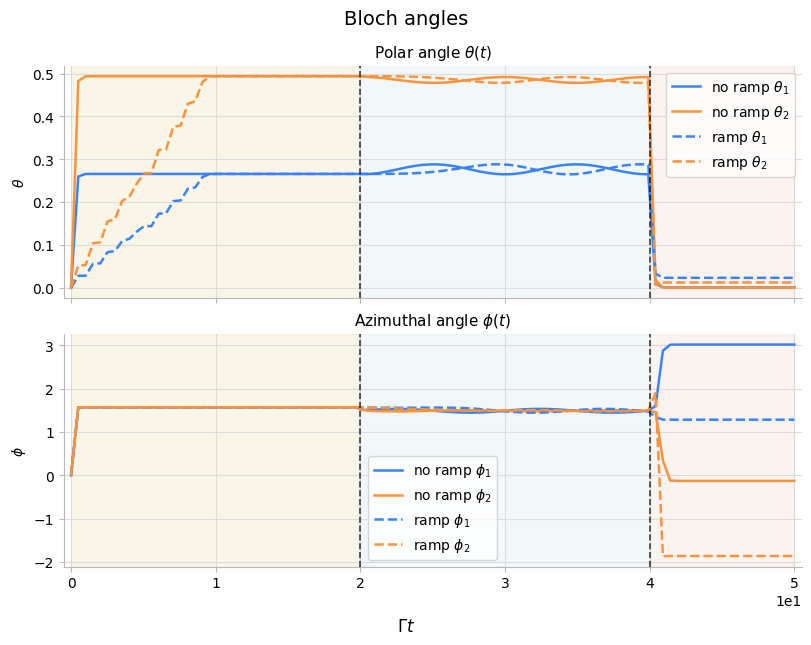

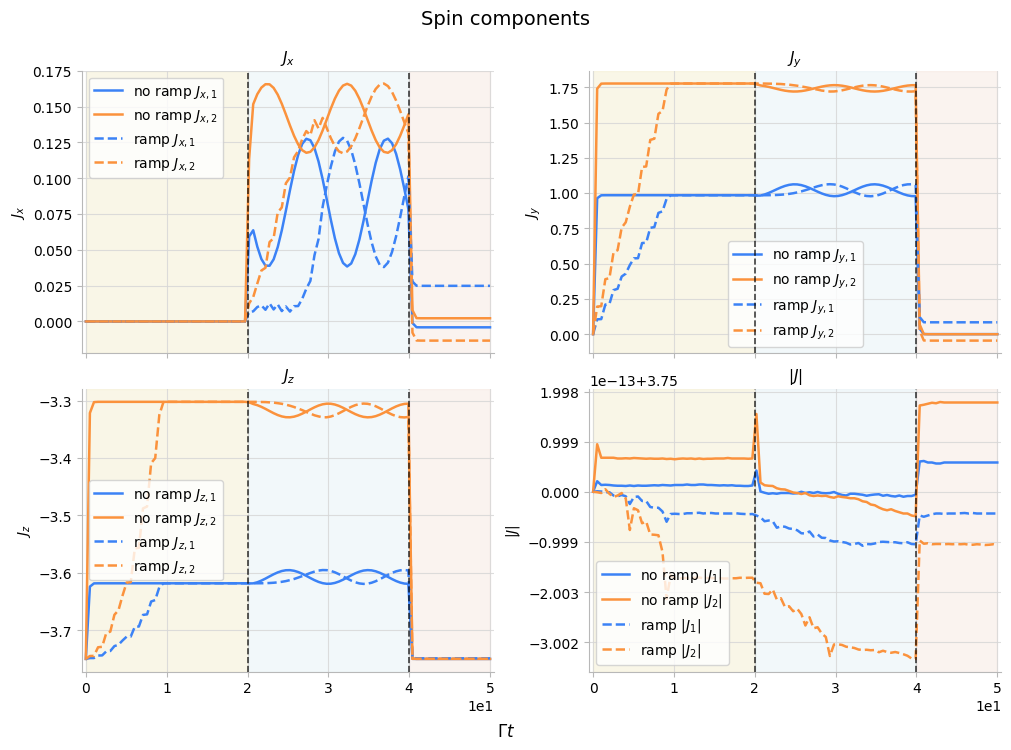

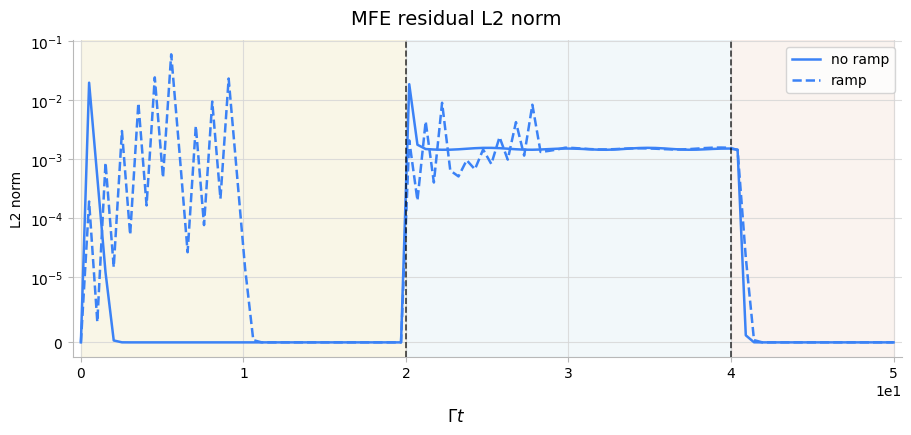

In [ ]:
from common.plotting import plot_bloch_angles, plot_mfe_residuals, plot_spin_components

fig, axes = plot_bloch_angles(
    mfe_moments.J.t,
    mfe_moments.J.theta_groups,
    mfe_moments.J.phi_groups,
    labels=[f"no ramp $J_{{{i}}}$" for i in range(1, len(mfe_moments.J.theta_groups) + 1)],
    phase_protocol=mfe_moments.metadata.phase_protocol,
    shade_index=2,
    linestyle="-",
)
fig, axes = plot_bloch_angles(
    mfe_moments_ramp.J.t,
    mfe_moments_ramp.J.theta_groups,
    mfe_moments_ramp.J.phi_groups,
    labels=[f"ramp $J_{{{i}}}$" for i in range(1, len(mfe_moments_ramp.J.theta_groups) + 1)],
    phase_protocol=mfe_moments_ramp.metadata.phase_protocol,
    shade_index=2,
    linestyle="--",
    axes=axes,
    # output_path=f"{output_dir}/parameter_ramp/angles_mfe",
)

fig, axes = plot_spin_components(
    mfe_moments.J.t,
    mfe_moments.J.x_groups,
    mfe_moments.J.y_groups,
    mfe_moments.J.z_groups,
    mfe_moments.J.length_groups,
    labels=[f"no ramp $J_{{{i}}}$" for i in range(1, len(mfe_moments.J.x_groups) + 1)],
    phase_protocol=mfe_moments.metadata.phase_protocol,
    shade_index=2,
    linestyle="-",
)
fig, axes = plot_spin_components(
    mfe_moments_ramp.J.t,
    mfe_moments_ramp.J.x_groups,
    mfe_moments_ramp.J.y_groups,
    mfe_moments_ramp.J.z_groups,
    mfe_moments_ramp.J.length_groups,
    labels=[f"ramp $J_{{{i}}}$" for i in range(1, len(mfe_moments_ramp.J.x_groups) + 1)],
    phase_protocol=mfe_moments_ramp.metadata.phase_protocol,
    shade_index=2,
    linestyle="--",
    axes=axes,
    # output_path=f"{output_dir}/parameter_ramp/spins_mfe",
)

fig, axes = plot_mfe_residuals(
    mfe_moments.mfe_residuals,
    phase_protocol=mfe_moments.metadata.phase_protocol,
    show_components=False,
    label="no ramp",
    shade_index=2,
    linestyle="-",
)
fig, axes = plot_mfe_residuals(
    mfe_moments_ramp.mfe_residuals,
    phase_protocol=mfe_moments_ramp.metadata.phase_protocol,
    show_components=False,
    label="ramp",
    shade_index=2,
    linestyle="--",
    axes=axes,
    # output_path=f"{output_dir}/parameter_ramp/mfe_residuals_mfe",
)
